In [84]:
# Imports
import math
import random
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

In [85]:
# Seed
set_seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [86]:
# Load data
jokes_df = pd.read_csv("data.csv").drop(columns=["ID"])
jokes_df.head()

,Joke
0,What did the bartender say to the jumper cable...
1,Don't you hate jokes about German sausage? The...
2,Two artists had an art contest... It ended in ...
3,Why did the chicken cross the playground? To g...
4,What gun do you use to hunt a moose? A moosecut!


In [87]:
# Split
dataset = Dataset.from_pandas(jokes_df, preserve_index=False)
dataset = dataset.train_test_split(test_size=0.2, seed=42, shuffle=True)

train = dataset["train"]
test = dataset["test"]

print(len(train), len(test))

1297 325


In [88]:
# Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2")
tokenizer.pad_token = tokenizer.eos_token

In [89]:
# Tokenize
def tokenize(batch):
    return tokenizer(batch["Joke"], truncation=True)

In [90]:
# Apply tokenization
tokenized_train = train.map(tokenize, batched=True, remove_columns=train.column_names)
tokenized_test = test.map(tokenize, batched=True, remove_columns=test.column_names)

Map: 100%|██████████| 325/325 [00:00<00:00, 12130.79 examples/s]


In [91]:
# Group text
block_size = 128

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated["input_ids"])
    total_length = (total_length // block_size) * block_size

    result = {
        k: [t[i:i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

In [92]:
# Build blocks
blocked_tokenized_train = tokenized_train.map(group_texts, batched=True)
blocked_tokenized_test = tokenized_test.map(group_texts, batched=True)

print(len(blocked_tokenized_train), len(blocked_tokenized_test))

Map: 100%|██████████| 325/325 [00:00<00:00, 17650.74 examples/s]

200 51


In [93]:
# Collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

In [94]:
# Baseline model
model_v1 = GPT2LMHeadModel.from_pretrained("openai-community/gpt2")
model_v1.config.pad_token_id = tokenizer.eos_token_id

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7326.99it/s]


In [95]:
# Baseline trainer
training_args_v1 = TrainingArguments(
    output_dir="./gpt2-jokes-v1",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=8,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    logging_steps=10,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer_v1 = Trainer(
    model=model_v1,
    args=training_args_v1,
    train_dataset=blocked_tokenized_train,
    eval_dataset=blocked_tokenized_test,
    data_collator=data_collator,
)

In [96]:
# Train v1
trainer_v1.train()

Epoch,Training Loss,Validation Loss
1,4.276160,3.976927
2,4.026752,3.872631
3,3.887661,3.812096
4,3.765596,3.787071
5,3.749192,3.766381
6,3.611911,3.756946
7,3.630755,3.751467
8,3.602810,3.749838


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]
There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=200, training_loss=3.8166964149475096, metrics={'train_runtime': 52.0521, 'train_samples_per_second': 30.738, 'train_steps_per_second': 3.842, 'total_flos': 104516812800000.0, 'train_loss': 3.8166964149475096, 'epoch': 8.0})

In [97]:
# Helpers
def get_best_eval_result(trainer, label):
    eval_logs = [x for x in trainer.state.log_history if "eval_loss" in x]

    if not eval_logs:
        print(f"No eval logs found for {label}.")
        return None

    best_eval = min(eval_logs, key=lambda x: x["eval_loss"])
    result = {
        "eval_loss": best_eval["eval_loss"],
        "epoch": best_eval.get("epoch"),
        "step": best_eval.get("step"),
    }

    print(label, result)

    try:
        print(label, "perplexity:", math.exp(result["eval_loss"]))
    except OverflowError:
        print(label, "perplexity: overflow")

    return result

def plot_losses(trainer, title):
    log_history = trainer.state.log_history

    train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    eval_logs = [x for x in log_history if "eval_loss" in x]

    if not train_logs or not eval_logs:
        print("Missing train or eval logs.")
        return

    train_steps = [x["step"] for x in train_logs]
    train_losses = [x["loss"] for x in train_logs]

    eval_steps = [x["step"] for x in eval_logs]
    eval_losses = [x["eval_loss"] for x in eval_logs]

    plt.figure(figsize=(8, 5))
    plt.plot(train_steps, train_losses, label="train_loss")
    plt.plot(eval_steps, eval_losses, label="eval_loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

def generate_joke(model, prompt, max_new_tokens=60):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            top_k=50,
            repetition_penalty=1.1,
            no_repeat_ngram_size=2,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

v1 {'eval_loss': 3.749838352203369, 'epoch': 8.0, 'step': 200}
v1 perplexity: 42.51420911635533


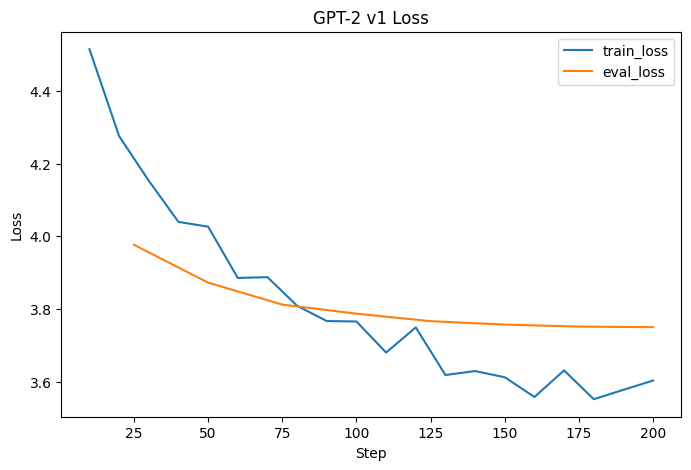

In [98]:
# V1 results
eval_results_v1 = get_best_eval_result(trainer_v1, "v1")
plot_losses(trainer_v1, "GPT-2 v1 Loss")

In [99]:
# V1 generations
dataset_prompt = " ".join(train[0]["Joke"].split()[:3])
random_prompt = "penguins love pizza"

print("Dataset prompt:", dataset_prompt)
print(generate_joke(trainer_v1.model, dataset_prompt, max_new_tokens=60))

print("\nRandom prompt:", random_prompt)
print(generate_joke(trainer_v1.model, random_prompt, max_new_tokens=60))

Dataset prompt: what keeps the
what keeps the world running for six months? You know what that's gonna be.You're probably wondering why it hasn't been cleaned up by now... because you've never seen anything like this one before in your life! But then there was an earthquake and many people died....Why did Captain Hook go to Greece

Random prompt: penguins love pizza
penguins love pizza? I've heard he always says it's only after a fight.What do you call one of the little fellas in town that never goes to church anymore?! A pugnacious, unhinged jerk!!!Why did everyone watch The Sopranos once before they left for college (when


In [100]:
# Fresh v2
model_v2 = GPT2LMHeadModel.from_pretrained("openai-community/gpt2")
model_v2.config.pad_token_id = tokenizer.eos_token_id

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7537.67it/s]


In [101]:
# V2 trainer
training_args_v2 = TrainingArguments(
    output_dir="./gpt2-jokes-v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.5e-5,
    weight_decay=0.01,
    warmup_ratio=0.10,
    num_train_epochs=15,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    logging_steps=10,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=blocked_tokenized_train,
    eval_dataset=blocked_tokenized_test,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [102]:
# Train v2
trainer_v2.train()

Epoch,Training Loss,Validation Loss
1,4.542752,4.192667
2,4.224177,3.980775
3,4.039702,3.876630
4,3.880480,3.827227
5,3.834716,3.790207
6,3.661502,3.770895
7,3.650690,3.753882
8,3.585164,3.745053
9,3.514882,3.739503
10,3.476150,3.737191


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]
There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=375, training_loss=3.690837651570638, metrics={'train_runtime': 99.8081, 'train_samples_per_second': 30.058, 'train_steps_per_second': 3.757, 'total_flos': 195969024000000.0, 'train_loss': 3.690837651570638, 'epoch': 15.0})

v2 {'eval_loss': 3.7308998107910156, 'epoch': 14.0, 'step': 350}
v2 perplexity: 41.71662835331925


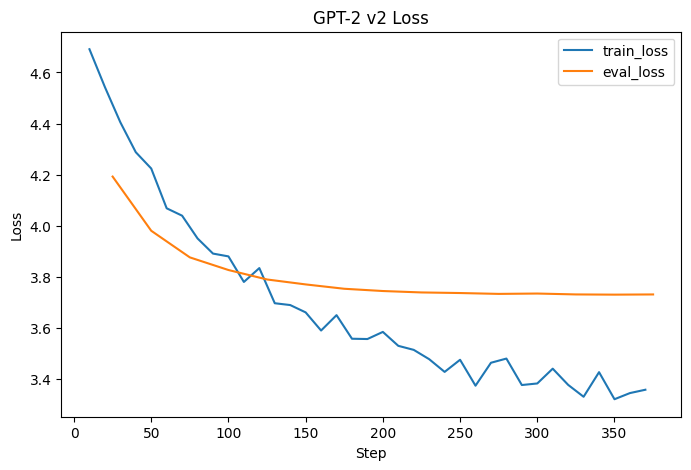

In [103]:
# V2 results
eval_results_v2 = get_best_eval_result(trainer_v2, "v2")
plot_losses(trainer_v2, "GPT-2 v2 Loss")

In [104]:
# Compare
results_df = pd.DataFrame(
    {
        "model": ["v1", "v2"],
        "eval_loss": [eval_results_v1["eval_loss"], eval_results_v2["eval_loss"]],
        "perplexity": [
            math.exp(eval_results_v1["eval_loss"]),
            math.exp(eval_results_v2["eval_loss"]),
        ],
    }
).sort_values("eval_loss")

results_df

,model,eval_loss,perplexity
1,v2,3.730900,41.716628
0,v1,3.749838,42.514209


In [105]:
# V2 generations
print("Dataset prompt:", dataset_prompt)
print(generate_joke(trainer_v2.model, dataset_prompt, max_new_tokens=60))

print("\nRandom prompt:", random_prompt)
print(generate_joke(trainer_v2.model, random_prompt, max_new_tokens=60))

Dataset prompt: what keeps the
what keeps the dog happy? He knows.My mom used to use two rows of paper towels, one with a hole in it and another for dirty dishes (she thought they were too heavy!). Then she found this wayward bear :)Did you know that people's best friend has an invisible ear!How do we

Random prompt: penguins love pizza
penguins love pizza.Why did the blacksmith's cat drop out of bed? He had a very sick bowl with no air conditioning!What kind is Robin Hood dressed up as in commercials and games?"Just make sure you pick what works for your business" - A man tells his wife he wants to buy an instrument


In [106]:
# Compare
results_df = pd.DataFrame(
    {
        "model": ["v1", "v2"],
        "eval_loss": [eval_results_v1["eval_loss"], eval_results_v2["eval_loss"]],
        "perplexity": [
            math.exp(eval_results_v1["eval_loss"]),
            math.exp(eval_results_v2["eval_loss"]),
        ],
        "epoch": [eval_results_v1["epoch"], eval_results_v2["epoch"]],
    }
).sort_values("eval_loss")

results_df

,model,eval_loss,perplexity,epoch
1,v2,3.730900,41.716628,14.0
0,v1,3.749838,42.514209,8.0


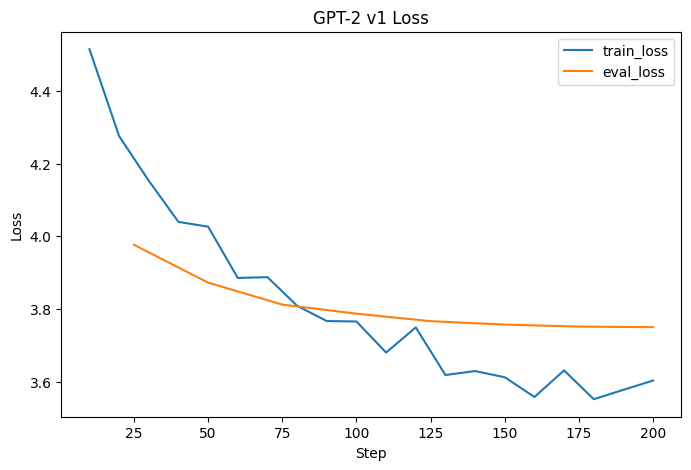

In [107]:
# V1 loss plot
log_history_v1 = trainer_v1.state.log_history

train_logs_v1 = [x for x in log_history_v1 if "loss" in x and "eval_loss" not in x]
eval_logs_v1 = [x for x in log_history_v1 if "eval_loss" in x]

train_steps_v1 = [x["step"] for x in train_logs_v1]
train_losses_v1 = [x["loss"] for x in train_logs_v1]

eval_steps_v1 = [x["step"] for x in eval_logs_v1]
eval_losses_v1 = [x["eval_loss"] for x in eval_logs_v1]

plt.figure(figsize=(8, 5))
plt.plot(train_steps_v1, train_losses_v1, label="train_loss")
plt.plot(eval_steps_v1, eval_losses_v1, label="eval_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("GPT-2 v1 Loss")
plt.legend()
plt.show()

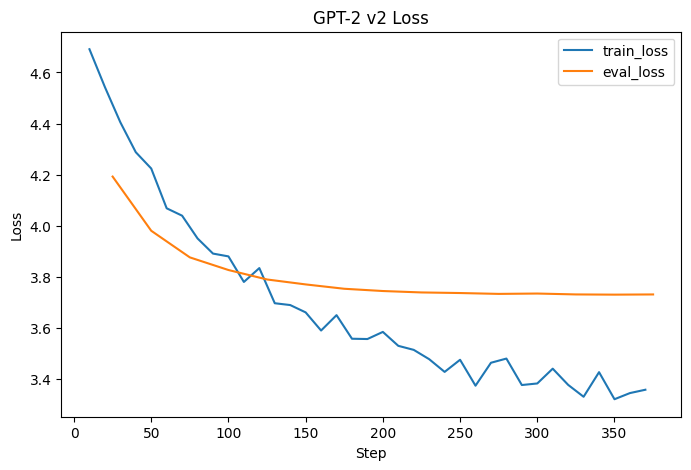

In [108]:
# V2 loss plot
log_history_v2 = trainer_v2.state.log_history

train_logs_v2 = [x for x in log_history_v2 if "loss" in x and "eval_loss" not in x]
eval_logs_v2 = [x for x in log_history_v2 if "eval_loss" in x]

train_steps_v2 = [x["step"] for x in train_logs_v2]
train_losses_v2 = [x["loss"] for x in train_logs_v2]

eval_steps_v2 = [x["step"] for x in eval_logs_v2]
eval_losses_v2 = [x["eval_loss"] for x in eval_logs_v2]

plt.figure(figsize=(8, 5))
plt.plot(train_steps_v2, train_losses_v2, label="train_loss")
plt.plot(eval_steps_v2, eval_losses_v2, label="eval_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("GPT-2 v2 Loss")
plt.legend()
plt.show()

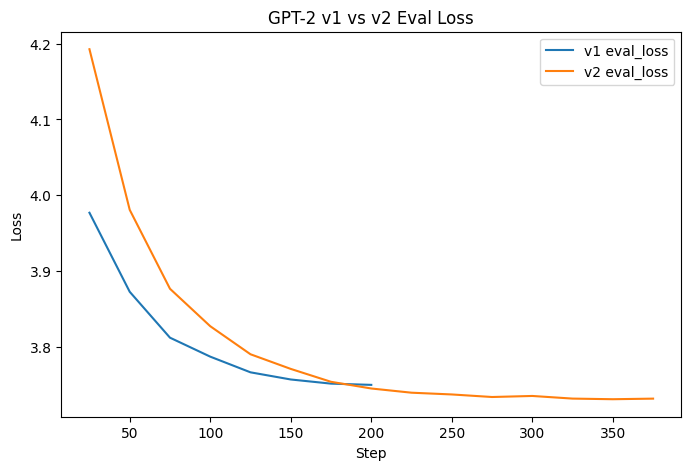

In [109]:
# Combined plot
plt.figure(figsize=(8, 5))
plt.plot(eval_steps_v1, eval_losses_v1, label="v1 eval_loss")
plt.plot(eval_steps_v2, eval_losses_v2, label="v2 eval_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("GPT-2 v1 vs v2 Eval Loss")
plt.legend()
plt.show()